<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [6]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [8]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_al = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_al = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nut = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [11]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [12]:
#Consulter le nombre de colonnes
population.columns
#La nature des données dans chacune des colonnes
population.dtypes
#Le nombre de valeurs présentes dans chacune des colonnes
population.count()

Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [13]:
#Affichage les 5 premières lignes de la table
population.head()


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [14]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur']=population['Valeur']*1000


In [15]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)


In [16]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()


,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [18]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_al.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_al.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [19]:
#Consulter le nombre de colonnes
dispo_al.shape[1]

18

In [20]:
#Affichage les 5 premières lignes de la table
dispo_al.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [21]:
#remplacement des NaN dans le dataset par des 0
dispo_al.fillna(0, inplace=True)


In [22]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
col_cible = [
    'Aliments pour animaux',
    'Autres Utilisations',
    'Disponibilité intérieure',
    'Exportations - Quantité',
    'Importations - Quantité',
    'Nourriture',
    'Pertes',
    'Production',
    'Semences',
    'Traitement',
    'Variation de stock'
]

dispo_al[col_cible] = dispo_al[col_cible] * 1_000_000


In [23]:
#Affichage les 5 premières lignes de la table
dispo_al.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [25]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_al.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_al.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [26]:
#Consulter le nombre de colonnes
aide_al.shape[1]

4

In [27]:
#Affichage les 5 premières lignes de la table
aide_al.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [28]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_al.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [29]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_al['Valeur']=aide_al['Valeur']*1000

In [30]:
#Affichage les 5 premières lignes de la table
aide_al.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [32]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nut.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nut.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [33]:
#Consulter le nombre de colonnes
sous_nut.shape[1]

3

In [34]:
#Afficher les 5 premières lignes de la table
sous_nut.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [35]:
#Conversion de la colonne sous nutrition en numérique
sous_nut['Valeur'] = pd.to_numeric(sous_nut['Valeur'], errors='coerce')

In [36]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nut.fillna(0, inplace=True)

In [37]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nut.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

In [38]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nut['sous_nutrition']=sous_nut['sous_nutrition']*1_000_000

In [39]:
#Afficher les 5 premières lignes de la table
sous_nut.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [41]:
#perso : création sous table sous_nut pour filtre 2017
sous_nut_2017 = sous_nut[sous_nut['Année'] == '2016-2018']

In [42]:
#perso : création sous table spopulation pour filtre 2017
population_2017 = population[population['Année'] == 2017]

In [43]:
# Suppression de la colonne Année de la table population
population_2017.drop(['Année'], axis=1)

,Zone,Population
4,Afghanistan,36296113.0
10,Afrique du Sud,57009756.0
16,Albanie,2884169.0
22,Algérie,41389189.0
28,Allemagne,82658409.0
...,...,...
1390,Venezuela (République bolivarienne du),29402484.0
1396,Viet Nam,94600648.0
1402,Yémen,27834819.0
1408,Zambie,16853599.0


In [44]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
df_joint = population_2017.merge(sous_nut_2017, on='Zone', how='inner')


In [45]:
#Affichage du dataset
df_joint.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0


In [46]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
nb_pers_sous_nut = df_joint['sous_nutrition'].sum()
nb_pers_sous_nut


535700000.0

In [47]:
# Calcul du % de la population en sous-nutrition. Création variable population totale
pop_totale = df_joint['Population'].sum()
print("Population totale en 2017 : {:,}.".format(round(pop_totale)).replace(",", " "))

Population totale en 2017 : 7 543 798 779.


In [48]:
# Calcul du % de la population en sous-nutrition. Division en utilisant les VAR
proportion_sous_nut = (nb_pers_sous_nut/pop_totale)*100
proportion_sous_nut.round(2)

7.1

In [49]:
print("Le pourcentage de la population en sous-nutrition est ",proportion_sous_nut.round(2))

Le pourcentage de la population en sous-nutrition est  7.1


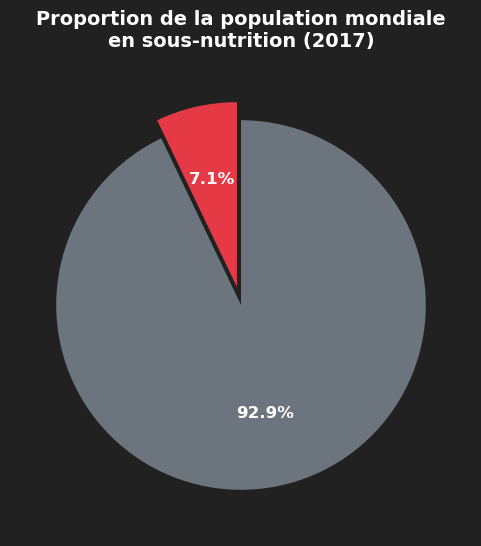

In [50]:
#dataviz
# Calcul de la proportion
proportion_sous_nut = (nb_pers_sous_nut / pop_totale) * 100
proportion_autre = 100 - proportion_sous_nut

# Données pour le camembert
valeurs = [proportion_sous_nut, proportion_autre]
labels = ["", ""]
couleurs = ["#e63946", "#6c757d"]
explode = [0.1, 0]  # 🔹 Décalage visuel du premier segment

# Création du camembert
plt.figure(figsize=(6, 6), facecolor="#212121")
plt.pie(
    valeurs,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=couleurs,
    textprops={"color": "white", "fontsize": 12, "weight": "bold"},
    explode=explode  # 🔹 Mise en avant du segment sous-nutrition
)
plt.title("Proportion de la population mondiale\nen sous-nutrition (2017)", color="white", fontsize=14, weight="bold", pad=20)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [52]:
#Combien mange en moyenne un être humain ? Source => https://www.who.int/fr/news-room/fact-sheets/detail/healthy-diet
besoin_moy_pers = 2200

In [53]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
df_joint_2 = population_2017.merge(dispo_al, on='Zone', how='inner')


In [54]:
#Affichage du nouveau dataframe
df_joint_2.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [55]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
df_joint_2["dispo_kcal"] = df_joint_2["Population"] * df_joint_2["Disponibilité alimentaire (Kcal/personne/jour)"]

In [56]:
##somme col dispo_kcal
sum_dispo_kcal = df_joint_2["dispo_kcal"].sum()
sum_dispo_kcal

20918984627331.0

In [57]:
#Calcul du nombre d'humains pouvant être nourris
nb_humains_nourris = sum_dispo_kcal / besoin_moy_pers
print("Le nombre de personnes pouvant être nourries est {:,}.".format(round(nb_humains_nourris)).replace(",", " "))

Le nombre de personnes pouvant être nourries est 9 508 629 376.


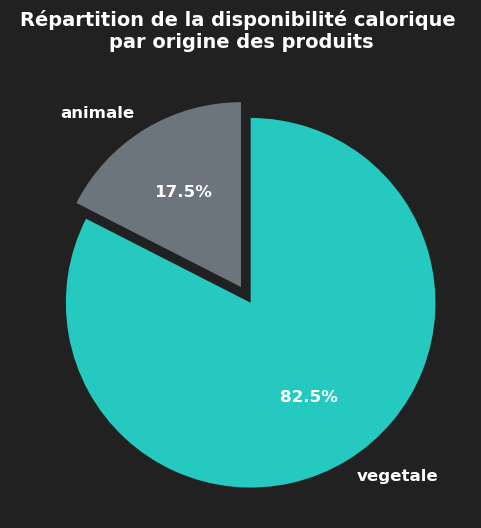

In [58]:
#dataviz
# Agréger les calories par Origine
df_grouped = df_joint_2.groupby('Origine')['dispo_kcal'].sum()

# Définir les couleurs personnalisées (à adapter selon tes préférences)
couleurs_personnalisees = ["#6c757d", "#26C9BF", "#3357ff", "#ff33a1", "#ffbd33", "#8c33ff", "#33ffd5"]

# Création de l'explosion pour le segment "Végétale"
explode = [0.1 if origine == "vegetale" else 0 for origine in df_grouped.index]  # 🔹 Décalage uniquement du segment végétal

# Création du graphique avec fond noir
plt.figure(figsize=(6, 6), facecolor='#212121')
plt.pie(
    df_grouped, 
    labels=df_grouped.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=couleurs_personnalisees,
    textprops={'color': 'white', 'fontsize': 12, 'weight': 'bold'},
    explode=explode  # 🔹 Ajout de l'explosion du segment végétal
)

# Titre en blanc avec mise en forme
plt.title("Répartition de la disponibilité calorique \npar origine des produits", color='white', fontsize=14, weight='bold')

# Affichage
plt.show()



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [60]:
#Transfert des données avec les végétaux dans un nouveau dataframe
df_joint_2_vegetaux = df_joint_2[df_joint_2["Origine"] == "vegetale"]


In [61]:
#Calcul du nombre de kcal disponible pour les végétaux
sum_kcal_vegetaux = df_joint_2_vegetaux["dispo_kcal"].sum()
sum_kcal_vegetaux

17260764211501.0

In [62]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humains_nourris_vegetaux = sum_kcal_vegetaux / besoin_moy_pers
print(f"Le nombre de personnes pouvant être nourris par des végétaux est {nb_humains_nourris_vegetaux} personnes")

Le nombre de personnes pouvant être nourris par des végétaux est 7845801914.318636 personnes


In [63]:
#Ratio sur la pop totale
nb_total_2 = (nb_humains_nourris_vegetaux / pop_totale)*100
print(f"Le ratio sur la population mondiale est de {nb_total_2.round(2)} %")

Le ratio sur la population mondiale est de 104.0 %


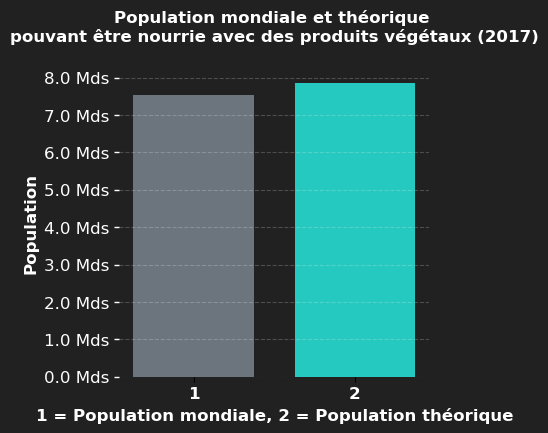

In [64]:
#dataviz
import matplotlib.pyplot as plt

# Données avec positions rapprochées
indices = [1, 1.4]  # 🔹 Rapprochement des barres (ajuste la deuxième valeur si besoin)
valeurs = [pop_totale, nb_humains_nourris_vegetaux]
couleurs = ["#6c757d", "#26C9BF"]  # Bleu = population totale, Vert = humains nourris par végétaux

# Création du graphique avec fond noir et taille ajustée
plt.figure(figsize=(4, 4), facecolor='#212121')  # 🔹 Taille plus compacte
plt.bar(indices, valeurs, color=couleurs, width=0.3)  # 🔹 Colonnes resserrées

# Personnalisation des textes
plt.xticks(indices, ["1", "2"], fontsize=12, fontweight='bold', color='white')  # 🔹 Labels X maintenus
plt.xlabel("1 = Population mondiale, 2 = Population théorique", fontsize=12, fontweight='bold', color='white')
plt.ylabel("Population", fontsize=12, fontweight='bold', color='white')
plt.title(
    "Population mondiale et théorique \npouvant être nourrie avec des produits végétaux (2017)",
    fontsize=12,
    fontweight='bold',
    color='white',
    loc='center',
    pad=20
)

# Suppression des bordures + formatage de l’axe Y
ax = plt.gca()
ax.set_facecolor('#212121')
plt.grid(axis="y", linestyle="--", alpha=0.2, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='y', colors='white', labelsize=12, width=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e9:.1f} Mds"))

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [66]:
#Calcul de la disponibilité totale Production + Importations - Exportations + Variation de stock

dispo_totale = df_joint_2["Production"] + df_joint_2["Importations - Quantité"] - df_joint_2["Exportations - Quantité"] + df_joint_2["Variation de stock"]
dispo_totale.sum()

9734105000000.0

In [67]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes :
#Semences + Pertes + Nourriture + Aliments pour animaux + Traitement + Autres utilisations

colonnes = ["Semences", "Aliments pour animaux", "Pertes", "Nourriture", "Traitement", "Autres Utilisations"]
total_dispo_alimentaire = 0

for col in colonnes:
    print(f"Valeurs de {col} :")
    print(df_joint_2[col].sum())
    total_dispo_alimentaire = total_dispo_alimentaire + df_joint_2[col].sum()
    print("-" * 30)

print(total_dispo_alimentaire)

Valeurs de Semences :
153317000000.0
------------------------------
Valeurs de Aliments pour animaux :
1288002000000.0
------------------------------
Valeurs de Pertes :
452283000000.0
------------------------------
Valeurs de Nourriture :
4805525000000.0
------------------------------
Valeurs de Traitement :
2185641000000.0
------------------------------
Valeurs de Autres Utilisations :
858771000000.0
------------------------------
9743539000000.0


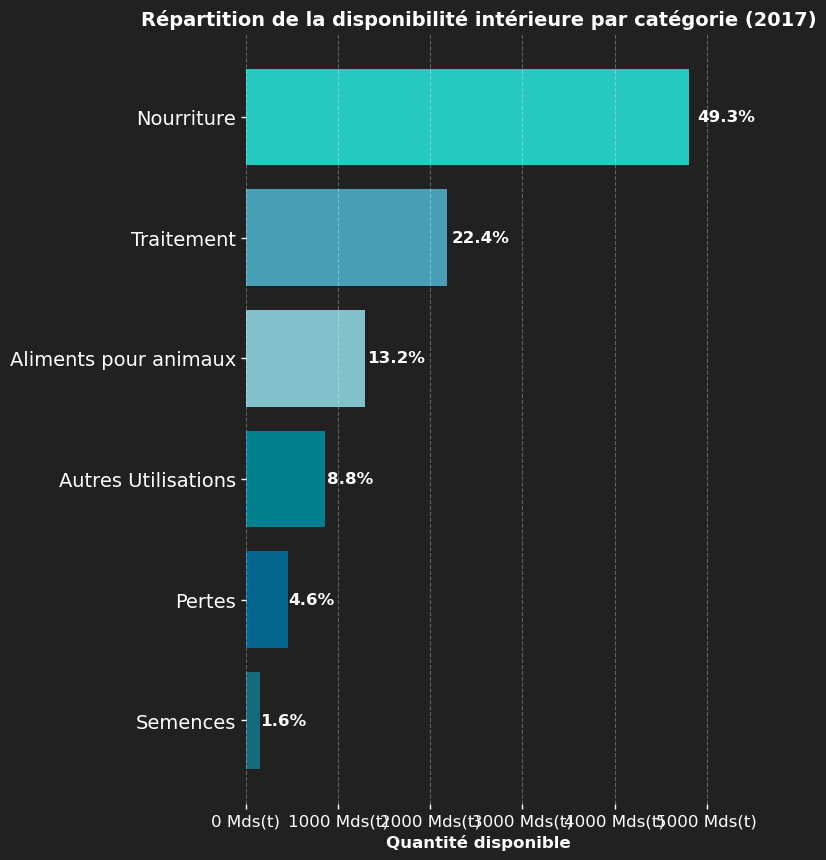

In [68]:
import matplotlib.ticker as ticker

#dataviz
# Sélection des colonnes pertinentes
colonnes = ["Semences", "Aliments pour animaux", "Pertes", "Nourriture", "Traitement", "Autres Utilisations"]
df_grouped = df_joint_2[colonnes].sum().sort_values(ascending=True)

# Calcul du pourcentage de chaque catégorie
total_disponibilite = df_grouped.sum()
df_pourcentage = (df_grouped / total_disponibilite) * 100

# Définition des couleurs spécifiques
couleurs_personnalisees = ["#16697a", "#05668d", "#028090", "#82c0cc", "#489fb5", "#26C9BF"]

# Création du graphique
plt.figure(figsize=(6, 10), facecolor="#212121")

plt.barh(df_grouped.index, df_grouped, color=couleurs_personnalisees)

# Ajout des pourcentages sur les barres
for i, (valeur, pourcentage) in enumerate(zip(df_grouped, df_pourcentage)):
    plt.text(valeur + (valeur * 0.02), i, f"{pourcentage:.1f}%", color="white", fontsize=12, fontweight="bold", va="center")

# Personnalisation du texte
plt.xlabel("Quantité disponible", fontsize=12, fontweight="bold", color="white")
plt.title("Répartition de la disponibilité intérieure par catégorie (2017)", fontsize=14, fontweight="bold", color="white")

# Suppression des bordures et grille ajustée
ax = plt.gca()
ax.set_facecolor("#212121")
plt.grid(axis="x", linestyle="--", alpha=0.3, color="white")
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", colors="white", labelsize=12, width=1)
ax.tick_params(axis="y", colors="white", labelsize=14, width=1)

# Formatage de l'axe X en milliards de tonnes
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e9:.0f} Mds(t)"))

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [70]:
#Création d'une liste avec toutes les variables
liste_variables = df_joint_2_vegetaux.columns.tolist()

In [71]:
print(liste_variables)

['Zone', 'Année', 'Population', 'Produit', 'Origine', 'Aliments pour animaux', 'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock', 'dispo_kcal']


In [72]:
#Création d'un dataframe avec les informations uniquement pour ces céréales (montrer les valeurs uniques de col Produit pour repérer les céréales)
sorted(df_joint_2_vegetaux['Produit'].unique())

['Agrumes, Autres',
 'Alcool, non Comestible',
 'Aliments pour enfants',
 'Ananas',
 'Arachides Decortiquees',
 'Avoine',
 'Bananes',
 'Bananes plantains',
 'Bière',
 'Blé',
 'Boissons Alcooliques',
 'Boissons Fermentés',
 'Café',
 'Citrons & Limes',
 'Coco (Incl Coprah)',
 'Céréales, Autres',
 'Dattes',
 'Edulcorants Autres',
 'Feve de Cacao',
 'Fruits, Autres',
 'Girofles',
 'Graines Colza/Moutarde',
 'Graines de coton',
 'Graines de tournesol',
 'Haricots',
 'Huil Plantes Oleif Autr',
 'Huile Graines de Coton',
 "Huile d'Arachide",
 "Huile d'Olive",
 'Huile de Coco',
 'Huile de Colza&Moutarde',
 'Huile de Germe de Maïs',
 'Huile de Palme',
 'Huile de Palmistes',
 'Huile de Soja',
 'Huile de Son de Riz',
 'Huile de Sésame',
 'Huile de Tournesol',
 'Ignames',
 'Légumes, Autres',
 'Légumineuses Autres',
 'Manioc',
 'Maïs',
 'Miel',
 'Millet',
 'Miscellanees',
 'Noix',
 'Oignons',
 'Olives',
 'Oranges, Mandarines',
 'Orge',
 'Palmistes',
 'Pamplemousse',
 'Patates douces',
 'Piments',
 

In [73]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereales = ['Avoine', 'Blé', 'Céréales, Autres', 'Maïs', 'Millet', 'Orge', 'Riz (Eq Blanchi)', 'Seigle', 'Sorgho']
df_cereales = df_joint_2_vegetaux[df_joint_2_vegetaux['Produit'].isin(cereales)]

In [74]:
#Affichage de la proportion d'alimentation animale
prop_alim_animale = (df_cereales['Aliments pour animaux'].sum() / df_cereales['Disponibilité intérieure'].sum()) * 100

In [75]:
df_cereales['Disponibilité intérieure'].sum()

2378371000000.0

In [76]:
#Affichage de la proportion d'alimentation animale
prop_alim_animale.round(1)

36.1

In [77]:
#Affichage de la proportion d'alimentation humaine
prop_alim_humaine = (df_cereales['Nourriture'].sum() / df_cereales['Disponibilité intérieure'].sum()) * 100
prop_alim_humaine.round(1)

42.9

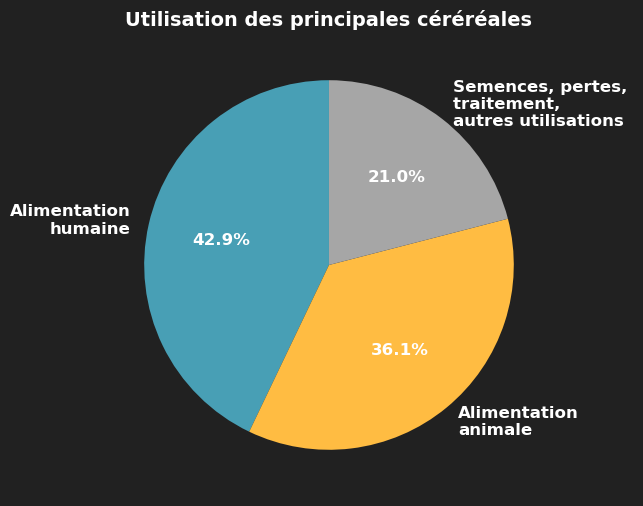

In [78]:
#dataviz
# Calcul des trois grandes catégories
total_dispo = df_cereales["Disponibilité intérieure"].sum()
valeurs = [
    df_cereales["Nourriture"].sum(),
    df_cereales["Aliments pour animaux"].sum(),
    df_cereales[["Semences", "Pertes", "Traitement", "Autres Utilisations"]].sum().sum()
]
labels = ["Alimentation\nhumaine", "Alimentation\nanimale", "Semences, pertes, \ntraitement, \nautres utilisations"]
couleurs = ["#489fb5", "#ffbc42", "#A6A6A6"]

# Création du camembert
plt.figure(figsize=(6,6), facecolor="#212121")
plt.pie(
    valeurs,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=couleurs,
    textprops={"color": "white", "fontsize": 12, "weight": "bold"}
)
plt.title("Utilisation des principales céréréales", color="white", fontsize=14, weight="bold")
plt.show()

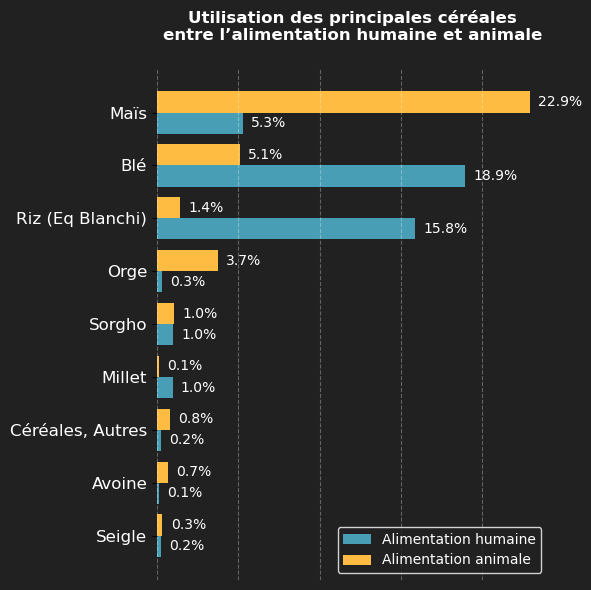

In [79]:
#dataviz
# Agrégation des données pour l'alimentation humaine et animale
df_grouped = df_cereales.groupby("Produit")[["Nourriture", "Aliments pour animaux"]].sum()

# Base de calcul : somme de la disponibilité intérieure
total_dispo = df_cereales["Disponibilité intérieure"].sum()

# Conversion en pourcentage par rapport à la disponibilité intérieure
df_pourcentage = df_grouped / total_dispo * 100

# **Tri des céréales par ordre décroissant de la disponibilité totale**
df_pourcentage["Total"] = df_pourcentage["Nourriture"] + df_pourcentage["Aliments pour animaux"]
df_pourcentage = df_pourcentage.sort_values("Total", ascending=True)

# Paramètres du graphique
labels = df_pourcentage.index
n = len(labels)
largeur = 0.4
x = np.arange(n)

# Création du graphique **horizontal**
plt.figure(figsize=(6, 6), facecolor="#212121")

plt.barh(x - largeur/2, df_pourcentage["Nourriture"], height=largeur, color="#489fb5", label="Alimentation humaine")
plt.barh(x + largeur/2, df_pourcentage["Aliments pour animaux"], height=largeur, color="#ffbc42", label="Alimentation animale")

# Ajout des pourcentages en face de chaque barre
for i in range(len(labels)):
    plt.text(df_pourcentage["Nourriture"].iloc[i] + 0.5, x[i] - largeur/2, f"{df_pourcentage['Nourriture'].iloc[i]:.1f}%", color="white", fontsize=10, va="center")
    plt.text(df_pourcentage["Aliments pour animaux"].iloc[i] + 0.5, x[i] + largeur/2, f"{df_pourcentage['Aliments pour animaux'].iloc[i]:.1f}%", color="white", fontsize=10, va="center")

# Personnalisation des axes et du titre avec espacement supplémentaire
plt.yticks(x, labels, fontsize=12, color="white")
plt.title("Utilisation des principales céréales\nentre l’alimentation humaine et animale", fontsize=12, color="white", weight="bold", pad=20)  # 🔹 Espacement amélioré

# Suppression des valeurs de l'axe X
ax = plt.gca()
ax.set_facecolor("#212121")
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)  # 🔹 Suppression complète des ticks et labels de X
plt.grid(axis="x", linestyle="--", color="white", alpha=0.3)

# Suppression des bordures superflues
for spine in ax.spines.values():
    spine.set_visible(False)

# 🔹 Réintégration de la légende
plt.legend(facecolor="#212121", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [81]:
#Création de la colonne proportion par pays
df_joint["proportion par pays"] = ((df_joint["sous_nutrition"] / df_joint["Population"]) * 100).round(1)
df_joint = df_joint.sort_values(by="proportion par pays", ascending=False)
df_joint.head()

,Zone,Année_x,Population,Année_y,sous_nutrition,proportion par pays
78,Haïti,2017,10982366.0,2016-2018,5300000.0,48.3
157,République populaire démocratique de Corée,2017,25429825.0,2016-2018,12000000.0,47.2
108,Madagascar,2017,25570512.0,2016-2018,10500000.0,41.1
103,Libéria,2017,4702226.0,2016-2018,1800000.0,38.3
100,Lesotho,2017,2091534.0,2016-2018,800000.0,38.2


In [82]:
## abreviation noms de pays 1 pour affichage graphique
#liste pays plus de 20 carac
df_joint_pays_long = df_joint[df_joint["Zone"].apply(lambda x: len(x) > 20)]["Zone"]
print(df_joint_pays_long.tolist())

['République populaire démocratique de Corée', 'Venezuela (République bolivarienne du)', 'République-Unie de Tanzanie', 'Bolivie (État plurinational de)', 'République dominicaine', "Iran (République islamique d')", 'Chine, Taiwan Province de', 'Papouasie-Nouvelle-Guinée', 'République arabe syrienne', 'République centrafricaine', 'République de Moldova', 'République démocratique du Congo', 'République démocratique populaire lao', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'Saint-Vincent-et-les Grenadines', 'Chine - RAS de Hong-Kong', "États-Unis d'Amérique", 'Micronésie (États fédérés de)']


In [83]:
## abreviation noms de pays 2 pour affichage graphique
abrev = {
    "République populaire démocratique de Corée": "Corée du Nord",
    "Venezuela (République bolivarienne du)": "Venezuela",
    "République-Unie de Tanzanie": "Tanzanie",
    "Bolivie (État plurinational de)": "Bolivie",
    "République dominicaine": "Rép. Dominicaine",
    "Iran (République islamique d')": "Iran",
    "Chine, Taiwan Province de": "Taïwan",
    "Papouasie-Nouvelle-Guinée": "PNG",
    "République arabe syrienne": "Syrie",
    "République centrafricaine": "Rép. Centrafricaine",
    "République de Moldova": "Moldova",
    "République démocratique du Congo": "RDC",
    "République démocratique populaire lao": "Laos",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "Saint-Vincent-et-les Grenadines": "Saint-Vincent",
    "Chine - RAS de Hong-Kong": "Hong Kong",
    "États-Unis d'Amérique": "USA",
    "Micronésie (États fédérés de)": "Micronésie"
}

# Appliquer les abréviations
df_joint["Zone"] = df_joint["Zone"].replace(abrev)

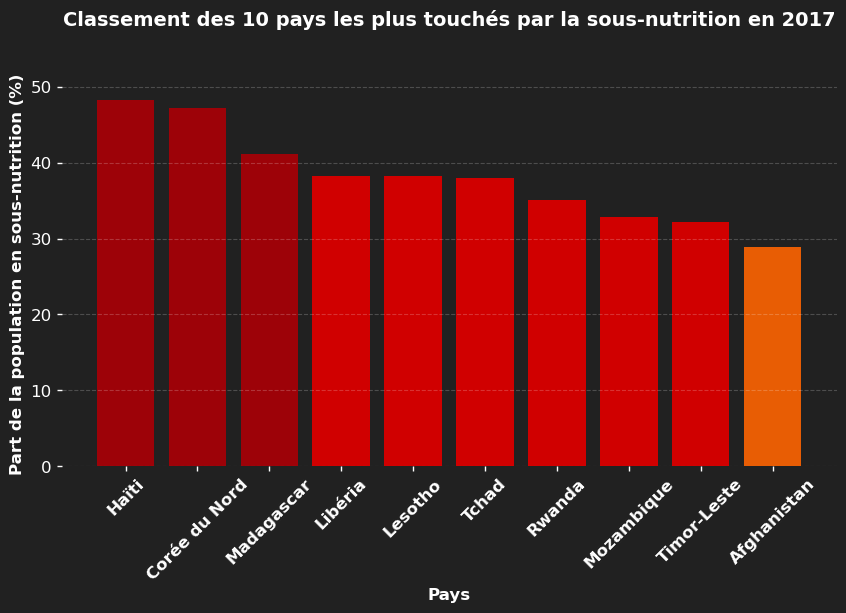

In [84]:
#dataviz
## df filtré sur les 10 pays avec la plus forte sous nut
df_top10 = df_joint.sort_values(by="proportion par pays", ascending=False).head(10)

def couleur_tranche(valeur):
    if valeur >= 40:
        return "#9d0208"
    elif valeur >= 30:
        return "#d00000"
    elif valeur >= 20:
        return "#e85d04"
    elif valeur >= 10:
        return "#f48c06"
    else:
        return "#faa307"

# Appliquer les couleurs aux données
df_top10["couleur"] = df_top10["proportion par pays"].apply(couleur_tranche)

# Créer la figure avec fond noir
plt.figure(figsize=(10, 5), facecolor='#212121')
plt.bar(df_top10["Zone"], df_top10["proportion par pays"], color=df_top10["couleur"])

# Personnalisation des textes
plt.xticks(rotation=45, fontsize=12, fontweight='bold', color='white')
plt.xlabel("Pays", fontsize=12, fontweight='bold', color='white')
plt.ylabel("Part de la population en sous-nutrition (%)", fontsize=12, fontweight='bold', color='white')
plt.title(
    "Classement des 10 pays les plus touchés par la sous-nutrition en 2017",
    fontsize=14,
    fontweight='bold',
    color='white',
    loc='center',
    pad=40
)

# Grille sur l’axe des Y, fond noir, suppression des bordures
ax = plt.gca()
ax.set_facecolor('#212121')
plt.grid(axis="y", linestyle="--", alpha=0.2, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)  # Suppression des bordures

ax.tick_params(axis='x', colors='white', labelsize=12, width=1)
ax.tick_params(axis='y', colors='white', labelsize=12, width=1)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [86]:
## affichage colonnes du df aide_al
print(aide_al.columns)

Index(['Zone', 'Année', 'Produit', 'Valeur'], dtype='object')


In [87]:
#calcul du total de l'aide alimentaire par pays
total_aide_par_pays = aide_al.groupby("Zone")["Valeur"].sum().reset_index()
total_aide_par_pays = total_aide_par_pays.sort_values(by="Valeur", ascending=False)
total_aide_par_pays

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
...,...,...
73,Égypte,1122000
69,Vanuatu,802000
67,Timor-Leste,116000
24,Géorgie,70000


In [88]:
## abreviation noms de pays 1 pour affichage graphique
#liste pays plus de 20 carac
total_aide_par_pays_long = total_aide_par_pays[total_aide_par_pays["Zone"].apply(lambda x: len(x) > 20)]["Zone"]
print(total_aide_par_pays_long.tolist())

['République arabe syrienne', 'République démocratique du Congo', 'République populaire démocratique de Corée', 'République-Unie de Tanzanie', 'République dominicaine', 'République centrafricaine', 'République démocratique populaire lao', "Iran (République islamique d')", 'Bolivie (État plurinational de)']


In [89]:
## abreviation noms de pays 2 pour affichage graphique
abrev_aide_al = {
    "République populaire démocratique de Corée": "Corée du Nord",
    "République-Unie de Tanzanie": "Tanzanie",
    "Bolivie (État plurinational de)": "Bolivie",
    "République dominicaine": "Rép. Dominicaine",
    "République arabe syrienne": "Syrie",
    "République centrafricaine": "Rép. Centrafricaine",
    "République démocratique du Congo": "RDC",
    "République démocratique populaire lao": "Laos",
}

# Appliquer les abréviations
total_aide_par_pays["Zone"] = total_aide_par_pays["Zone"].replace(abrev_aide_al)

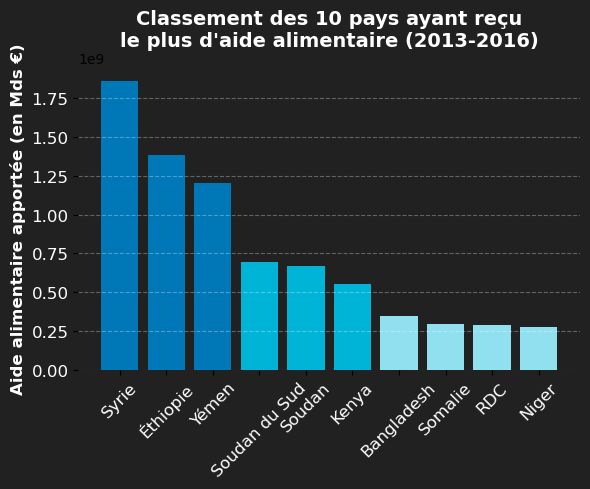

In [90]:
#dataviz
# Filtrage sur les 10 pays ayant reçu le plus d'aide alimentaire
total_aide_par_pays_top10 = total_aide_par_pays.sort_values(by="Valeur", ascending=False).head(10)

# Définition des couleurs par tranche
def couleur_tranche_aide_al(valeur):
    if valeur >= 1_000_000_000:
        return "#0077b6"
    elif valeur >= 500_000_000:
        return "#00b4d8"
    else:
        return "#90e0ef"

total_aide_par_pays_top10["couleur"] = total_aide_par_pays_top10["Valeur"].apply(couleur_tranche_aide_al)

# Création du graphique avec fond noir et sans bordures
plt.figure(figsize=(6, 5), facecolor="#212121")
plt.bar(total_aide_par_pays_top10["Zone"], total_aide_par_pays_top10["Valeur"], color=total_aide_par_pays_top10["couleur"])

# Personnalisation des axes
plt.xticks(rotation=45, fontsize=12, color="white")  # 🔹 Augmentation de la taille des étiquettes X
plt.yticks(fontsize=12, color="white")  # 🔹 Rendre les valeurs de l'axe Y visibles en blanc
plt.xlabel("")  # Suppression du label de l'axe X
plt.ylabel("Aide alimentaire apportée (en Mds €)", fontsize=12, color="white", weight="bold")
plt.title("Classement des 10 pays ayant reçu\nle plus d'aide alimentaire (2013-2016)", fontsize=14, color="white", weight="bold", pad=15)

# Suppression des bordures
ax = plt.gca()
ax.set_facecolor("#212121")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Grille ajustée
plt.grid(axis="y", linestyle="--", alpha=0.3, color="white")

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [92]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
df_aide_al_group = aide_al.groupby(["Zone", "Année"])["Valeur"].sum().reset_index()
df_aide_al_group


,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [93]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_df_aide_al_group_top5 = df_aide_al_group.groupby("Zone")["Valeur"].sum().nlargest(5).index.tolist()
liste_df_aide_al_group_top5


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [94]:
#On filtre sur le dataframe avec notre liste
df_aide_al_group_top5 = df_aide_al_group[df_aide_al_group["Zone"].isin(liste_df_aide_al_group_top5)]
df_aide_al_group_top5


,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


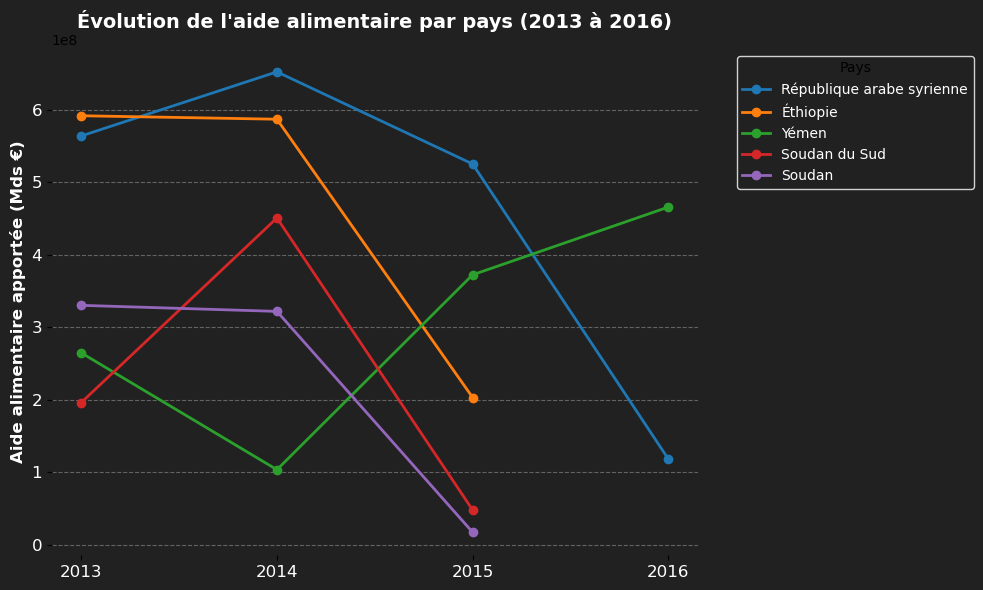

In [95]:
#dataviz
# Affichage des pays avec l'aide alimentaire par année
plt.figure(figsize=(10, 6), facecolor="#212121")  # 🔹 Fond noir

## 1 ligne par pays
for pays in liste_df_aide_al_group_top5:
    data_pays = df_aide_al_group_top5[df_aide_al_group_top5["Zone"] == pays]
    plt.plot(data_pays["Année"], data_pays["Valeur"], marker="o", label=pays, linewidth=2)

# Axe X : valeurs non continues (sans décimales)
plt.xticks(sorted(df_aide_al_group_top5["Année"].unique()), fontsize=12, color="white")
plt.yticks(fontsize=12, color="white")  # 🔹 Rendre les valeurs de l'axe Y visibles

plt.xlabel("")  # 🔹 Suppression du label de l'axe X
plt.ylabel("Aide alimentaire apportée (Mds €)", fontsize=12, color="white", weight="bold")
plt.title("Évolution de l'aide alimentaire par pays (2013 à 2016)", fontsize=14, color="white", weight="bold", pad=15)

# Ajout d'une grille subtile
plt.grid(axis="y", linestyle="--", alpha=0.3, color="white")

# Suppression des bordures superflues
ax = plt.gca()
ax.set_facecolor("#212121")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Positionnement de la légende
plt.legend(title="Pays", bbox_to_anchor=(1.05, 1), loc="upper left", facecolor="#212121", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [97]:
## Rappel baseW
print(dispo_al.columns)

Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')


In [98]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_kcal_par_pays = dispo_al.groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"].sum().reset_index()
dispo_kcal_par_pays



,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0
...,...,...
169,Émirats arabes unis,3275.0
170,Équateur,2346.0
171,États-Unis d'Amérique,3682.0
172,Éthiopie,2129.0


In [99]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
pays_moins_dispo = dispo_kcal_par_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True).head(10)
pays_moins_dispo['Zone'] = pays_moins_dispo['Zone'].replace('République populaire démocratique de Corée', 'Corée du Nord')
pays_moins_dispo

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,Corée du Nord,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
154,Timor-Leste,2129.0


In [100]:
pays_moins_dispo.columns

Index(['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)'], dtype='object')

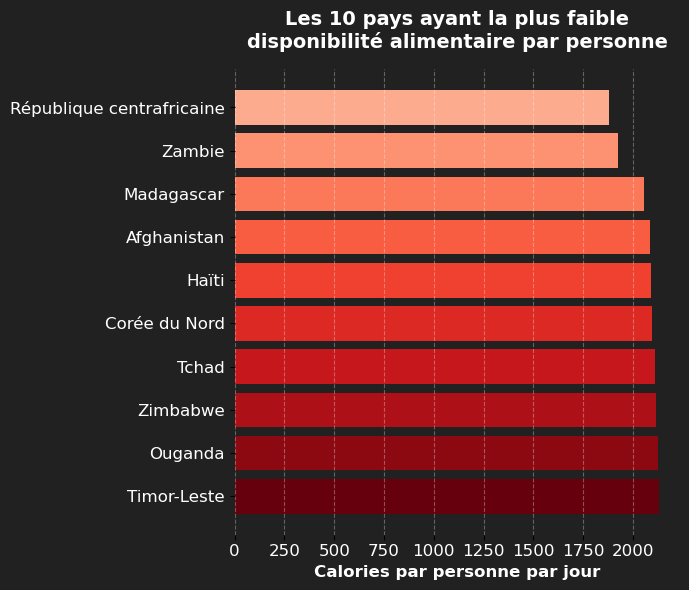

In [101]:
#dataviz
# Dégradé inversé : plus clair pour la valeur la plus élevée
couleurs = plt.cm.Reds(np.linspace(0.3, 1, len(pays_moins_dispo)))

# Création du graphique avec fond noir
plt.figure(figsize=(7, 6), facecolor="#212121")

# Barres horizontales avec couleurs inversées
plt.barh(pays_moins_dispo["Zone"], pays_moins_dispo["Disponibilité alimentaire (Kcal/personne/jour)"], color=couleurs)

# Personnalisation des axes
plt.xticks(fontsize=12, color="white")  # 🔹 Axe X en blanc
plt.yticks(fontsize=12, color="white")  # 🔹 Axe Y en blanc pour la lisibilité
plt.xlabel("Calories par personne par jour", fontsize=12, color="white", weight="bold")  # 🔹 Ajout de la légende X en blanc
plt.ylabel("")  # 🔹 Suppression du label de l'axe Y
plt.title("Les 10 pays ayant la plus faible\ndisponibilité alimentaire par personne", fontsize=14, color="white", weight="bold", pad=15)

# Ajout d’une grille subtile
plt.grid(axis="x", linestyle="--", alpha=0.3, color="white")

# Suppression des bordures superflues
ax = plt.gca()
ax.set_facecolor("#212121")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Inversion de l’axe Y pour afficher le pays avec la pire disponibilité en haut
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [103]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
pays_plus_dispo = dispo_kcal_par_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)
pays_plus_dispo

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


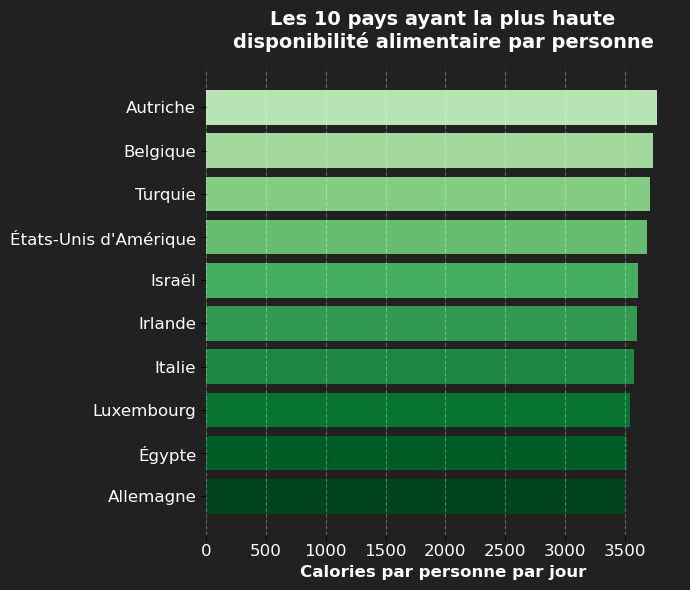

In [104]:
#dataviz
# Dégradé de vert personnalisé (plus clair pour la valeur la plus élevée)
couleurs = plt.cm.Greens(np.linspace(0.3, 1, len(pays_moins_dispo)))

# Création du graphique avec fond noir
plt.figure(figsize=(7, 6), facecolor="#212121")

# Barres horizontales avec couleurs personnalisées
plt.barh(pays_plus_dispo["Zone"], pays_plus_dispo["Disponibilité alimentaire (Kcal/personne/jour)"], color=couleurs)

# Personnalisation des axes et légende
plt.xticks(fontsize=12, color="white")  # 🔹 Axe X en blanc
plt.yticks(fontsize=12, color="white")  # 🔹 Axe Y en blanc pour la lisibilité
plt.xlabel("Calories par personne par jour", fontsize=12, color="white", weight="bold")  # 🔹 Ajout de la légende X en blanc
plt.ylabel("")
plt.title("Les 10 pays ayant la plus haute\ndisponibilité alimentaire par personne", fontsize=14, color="white", weight="bold", pad=15)

# Ajout d’une grille subtile
plt.grid(axis="x", linestyle="--", alpha=0.3, color="white")

# Suppression des bordures superflues
ax = plt.gca()
ax.set_facecolor("#212121")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Inversion de l’axe Y pour afficher le pays avec la meilleure disponibilité en haut
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [106]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_al_thailande = df_joint_2[(df_joint_2["Zone"] == "Thaïlande") & (df_joint_2["Produit"] == "Manioc")]
dispo_al_thailande

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
14166,Thaïlande,2017,69209810.0,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,...,6.264000e+09,2.521400e+10,1.250000e+09,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,2.768392e+09


In [107]:
df_joint_pop_thailande = df_joint[(df_joint["Zone"]=="Thaïlande")]
df_joint_pop_thailande_short = df_joint_pop_thailande.drop(columns=["Année_x", "Population", "Année_y"])
dispo_al_thailande_sous_nut = dispo_al_thailande.merge(df_joint_pop_thailande_short, on="Zone", how="inner")
dispo_al_thailande_sous_nut


,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal,sous_nutrition,proportion par pays
0,Thaïlande,2017,69209810.0,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,...,1.250000e+09,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,2.768392e+09,6200000.0,9.0


In [108]:
#Calcul de la sous nutrition en Thaïlande
valeur_proportion = dispo_al_thailande_sous_nut.loc[:, "proportion par pays"].values[0]
valeur_nb = dispo_al_thailande_sous_nut.loc[:, "sous_nutrition"].values[0]
phrase = f"La proportion de la population en sous-nutrition en Thaïlande est de {valeur_proportion} % - soit {valeur_nb:,.0f} personnes".replace(",", " ")
print(phrase)


La proportion de la population en sous-nutrition en Thaïlande est de 9.0 % - soit 6 200 000 personnes


In [109]:
dispo_tot_manioc_thailande = dispo_al_thailande_sous_nut["Production"] + dispo_al_thailande_sous_nut["Importations - Quantité"] - dispo_al_thailande_sous_nut["Exportations - Quantité"] + dispo_al_thailande_sous_nut["Variation de stock"]
print(dispo_tot_manioc_thailande.sum())
print(dispo_al_thailande_sous_nut["Exportations - Quantité"].sum())
print(dispo_al_thailande_sous_nut["Disponibilité intérieure"].sum())
print(dispo_al_thailande_sous_nut["Production"].sum())

6264000000.0
25214000000.0
6264000000.0
30228000000.0


In [110]:
# Extraction des valeurs du DataFrame filtré
exportations = dispo_al_thailande_sous_nut["Exportations - Quantité"].values[0]
production = dispo_al_thailande_sous_nut["Production"].values[0]

# Calcul de la proportion exportée (%)
proportion_exportee = (exportations / production) * 100

# Affichage du résultat avec un format lisible
print(f"La proportion exportée du manioc en Thaïlande est de {proportion_exportee:.2f} %.")

La proportion exportée du manioc en Thaïlande est de 83.41 %.


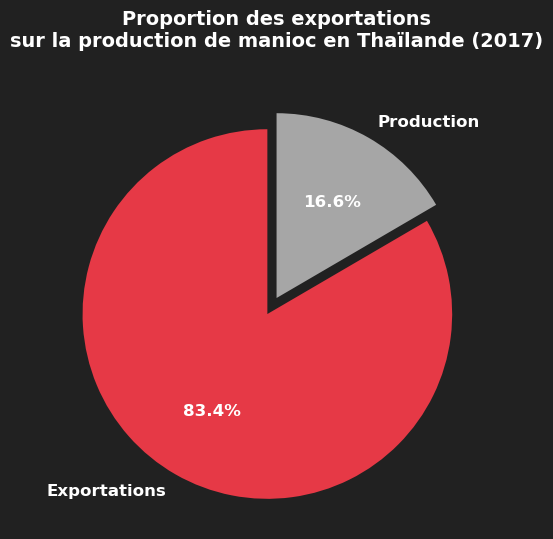

In [111]:
#dataviz
# Calcul de la proportion des exportations sur la production
proportion_exportation = (exportations / production) * 100
proportion_reste = 100 - proportion_exportation

# Données pour le graphique
valeurs = [proportion_exportation, proportion_reste]
labels = ["Exportations", "Production"]
couleurs = ["#e63946", "#A6A6A6"]  # 🔹 Rouge pour exportations, bleu pour consommation interne
explode = [0.1, 0]  # 🔹 Mise en avant des exportations

# Création du camembert
plt.figure(figsize=(6, 6), facecolor="#212121")
plt.pie(
    valeurs,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=couleurs,
    textprops={"color": "white", "fontsize":12, "weight":"bold"},
    explode=explode  # 🔹 Mise en avant du segment des exportations
)

# Titre
plt.title("Proportion des exportations\nsur la production de manioc en Thaïlande (2017)", color="white", fontsize=14, weight="bold", pad=15)

# Affichage
plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [113]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire"

In [114]:
# Calcul indice d'autosuffisance en céréales des 10 pays les plus touchés par la sous nutrition en 2017
pays_cibles = [
    "Haïti",
    "République populaire démocratique de Corée",
    "Madagascar",
    "Libéria",
    "Lesotho",
    "Tchad",
    "Rwanda",
    "Mozambique",
    "Timor-Leste",
    "Afghanistan"
]

# Filtrage du DataFrame source avec ces noms complets
df_cible = df_cereales[df_cereales['Zone'].isin(pays_cibles)].copy()

# Suppression des lignes problématiques pour le calcul
df_cible = df_cible[df_cible['Disponibilité intérieure'] > 0]

# Calcul de l'indice d'autosuffisance
df_cible['indice_autosuffisance'] = df_cible['Production'] / df_cible['Disponibilité intérieure']

# Moyenne par pays
df_indice_pays = (
    df_cible.groupby('Zone')['indice_autosuffisance']
    .mean(numeric_only=True)
    .sort_values()
    .reset_index()
)

df_indice_pays['Zone'] = df_indice_pays['Zone'].replace({
    "République populaire démocratique de Corée": "Corée du Nord"
})

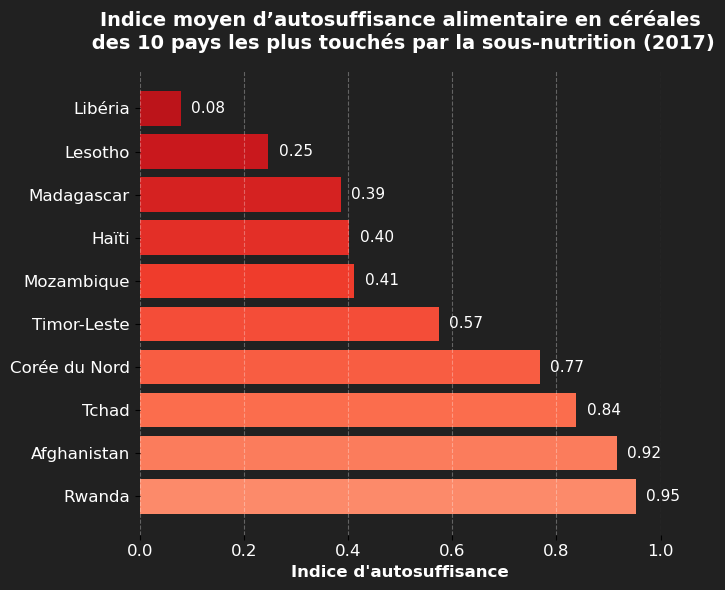

In [115]:
#dataviz
# Dégradé rouge clair à rouge foncé (valeurs basses à hautes)
couleurs = plt.cm.Reds(np.linspace(0.8, 0.4, len(df_indice_pays)))

# Création du graphique sur fond sombre
plt.figure(figsize=(7, 6), facecolor="#212121")

# Barplot horizontal
plt.barh(
    df_indice_pays['Zone'],
    df_indice_pays['indice_autosuffisance'],
    color=couleurs
)

# Personnalisation des axes
plt.xticks(fontsize=12, color="white")
plt.yticks(fontsize=12, color="white")
plt.xlabel("Indice d'autosuffisance", fontsize=12, color="white", weight="bold")
plt.title("Indice moyen d’autosuffisance alimentaire en céréales\n des 10 pays les plus touchés par la sous-nutrition (2017)", fontsize=14, color="white", weight="bold", pad=15)

# Grille subtile
plt.grid(axis="x", linestyle="--", alpha=0.3, color="white")

# Nettoyage des bordures et fond
ax = plt.gca()
ax.set_facecolor("#212121")
for spine in ax.spines.values():
    spine.set_visible(False)

# Affichage du pays le moins autonome en haut
plt.gca().invert_yaxis()

# Ajout des valeurs sur les barres
for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center', color='white', fontsize=11)

plt.tight_layout()
plt.show()